Adapt MatLab algorithm from Trefethen's paper to test ETD methods on the Kuramoto-Sivashinsky equation:
$$u_t = -u u_{x} - u_{xx} - u_{xxxx}$$
with periodic boundary conditions on $x \in [0, 32\pi]$.

In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('../utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np 
from scipy import sparse 
from scipy import fft
from matplotlib import pyplot as plt
from matplotlib import animation
from time import time

from ETD_solver import cheb

In [39]:
def KS_solver(N):

    # compute spatial grid and initial condition
    x = 32. * np.pi * np.arange(1, N+1) / N
    # x = np.linspace(-1, 1, N)
    u = np.cos(x / 16.) * (1. + np.sin(x / 16.))
    # u = np.cos(np.pi * x) + 0.1 * np.sin(2 * np.pi * x)
    v = fft.fft(u)

    # precompute ETD-RK4 scalar quantities
    h = 0.25                                                                        # time step
    k = np.concatenate([np.arange(0, N/2), [0.], np.arange(-N/2+1, 0)]) / 16.        # wave numbers / Nyquist frequency
    L = k**2 - k**4                                                  # Fourier multipliers
    E = np.exp(h * L)
    E2 = np.exp(h * L / 2.)
    
    M = 16                                                          # number of points for complex means
    r = np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)     # roots of unity
    LR = h * L[:, np.newaxis] + r[np.newaxis, :]
    Q = h * np.real(np.mean((np.exp(LR / 2.) - 1.) / LR, axis=1))
    f1 = h * np.real(np.mean((-4. - LR + np.exp(LR) * (4. - 3. * LR + LR**2)) / LR**3, axis=1))
    f2 = h * np.real(np.mean((2. + LR + np.exp(LR) * (-2. + LR)) / LR**3, axis=1))
    f3 = h * np.real(np.mean((-4. - 3. * LR - LR**2 + np.exp(LR) * (4. - LR)) / LR**3, axis=1))

    # main time-stepping loop 
    uu = u 
    tt = [0]
    tmax = 150
    nmax = int(np.round(tmax / h))
    nplt = int(np.floor((tmax / 100) / h))
    g = -0.5j * k

    print(nmax)
    for n in range(nmax):
        t = n * h 
        Nv = g * fft.fft(np.real(fft.ifft(v))**2)
        a = E2 * v + Q * Nv 
        Na = g * fft.fft(np.real(fft.ifft(a))**2)
        b = E2 * v + Q * Na 
        Nb = g * fft.fft(np.real(fft.ifft(b))**2)
        c = E2 * a + Q * (2. * Nb - Nv)
        Nc = g * fft.fft(np.real(fft.ifft(c))**2)
        v = (E * v) + (Nv * f1) + (2. * (Na + Nb) * f2) + (Nc * f3)
        
        if n % nplt == 0:
            u = np.real(fft.ifft(v))
            uu = np.vstack((uu, u))
            tt.append(t)
            
    return uu, np.array(tt), x

In [40]:
u, t, x = KS_solver(N=128)

600


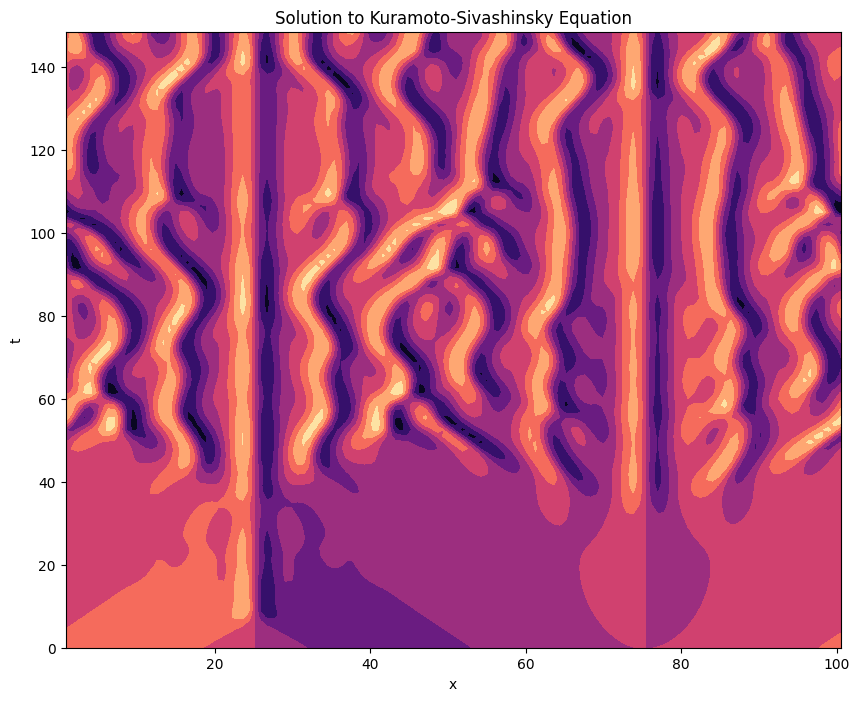

In [41]:
X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

ax.contourf(X, T, u, cmap="magma")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Solution to Kuramoto-Sivashinsky Equation")
plt.show()

Try to recreate a similar solution same solution using a non-Fourier ETD solver as defined by Cox and Matthews.

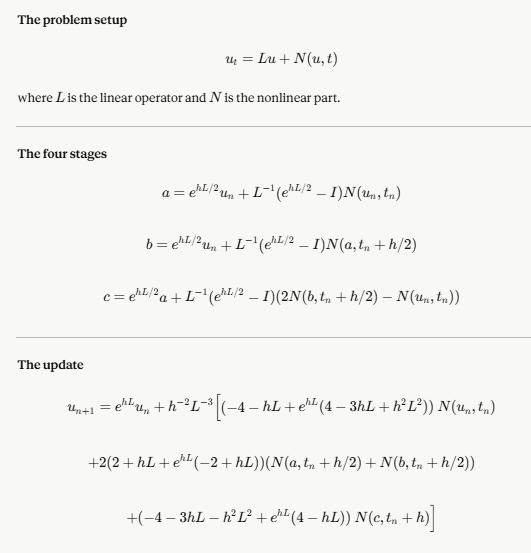

In [ ]:
def KS_solver_non_fourier(nx, tf, nt, u0):

    # generate the spatial grid (Chebyshev points) and compute initial state
    D, x = cheb(nx)
    u_init = u0(x)

    # define the temporal grid
    t_vals, h = np.linspace(0, tf, nt+1, retstep=True)

    # compute the interior of the linear operator for the KS equation
    D2 = D @ D 
    D4 = D2 @ D2 
    L = -D2 - D4 
    # slice out interior
    sl = np.s_[1:-1]
    L = L[sl, sl]

    # compute the exponential of the linear operator (full and half time steps)
    lam, V = np.linalg.eig(h * L)
    exp_L_full = V @ np.diag(np.exp(lam)) @ np.linalg.inv(V)
    lam, V = np.linalg.eig(h * L / 2.)
    exp_L_half = V @ np.diag(np.exp(lam)) @ np.linalg.inv(V)

    # compute and save inverse of linear operator
    L_inv = np.linalg.inv(L)
    L_inv_3 = L_inv @ L_inv @ L_inv
    I = np.eye(exp_L_half.shape[0])

    # define a function for the non-linear part 
    D_int = D[sl, sl]
    def N(u_curr):
        return -u_curr * (D_int @ u_curr) 
    
    # precompute coefficients for ETD-RK4
    

    # create solution array and define initial condition 
    U = np.empty((nt+1, nx+1))
    U[0, sl] = u_init[sl]

    # main time-stepping loop 
    for t in range(1, nt+1):
        u_curr = U[t-1, sl]
        a = exp_L_half @ u_curr + L_inv @ (exp_L_half - I) @ N(u_curr)
        b = exp_L_half @ u_curr + L_inv @ (exp_L_half - I) @ N(a)
        c = exp_L_half @ a + L_inv @ (exp_L_half - I) @ (2. * N(b) - N(u_curr))

        # update rule
        u_next = (
            exp_L_full @ u_curr 
            + h**(-2)
        )
    

SyntaxError: invalid syntax (4101003101.py, line 49)

In [44]:
D, x = cheb(4)
print(x.shape)

(5,)
